<a href="https://colab.research.google.com/github/Surya-Teja-PS/LLM-Evaluation-Framework/blob/main/LLM_Evaluation_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -U -q groq google-genai deepeval pandas matplotlib

/tmp/ipykernel_2807/3611481387.py:182: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, LLMTestCaseParams


[1/20] Friendly — What are LLMs?...


Output()

Output()

[2/20] Academic — What are LLMs?...


...

Rate limited (429, Groq). Waiting 40s before retry (2/5)...

Rate limited (429, Groq). Waiting 60s before retry (3/5)...

Rate limited (429, Groq). Waiting 80s before retry (4/5)...

Rate limited (429, Groq). Waiting 100s before retry (5/5)...

  Failed on this case (Max retries exceeded on API errors (429/503).). Saving progress so far and stopping.

=== Average manual-judge scores (out of 5) ===
accuracy     5.00
clarity      4.60
relevance    5.00
analogies    4.87
follow_up    4.93
persona      4.93
dtype: float64

=== Average manual-judge scores by persona ===
         accuracy  clarity  relevance  analogies  follow_up  persona
persona                                                             
4             5.0     4.00        5.0       5.00       5.00      4.0
5             5.0     4.64        5.0       4.86       4.93      5.0

=== Average manual-judge scores by difficulty ===
            accuracy  clarity  relevance  analogies  follow_up  persona
difficulty                                                             
easy             5.0      4.8        5.0       5.00        4.8      4.8
hard             5.0      4.5        5.0       4.50        5.0      5.0
medium           5.0      4.5        5.0       4.88       

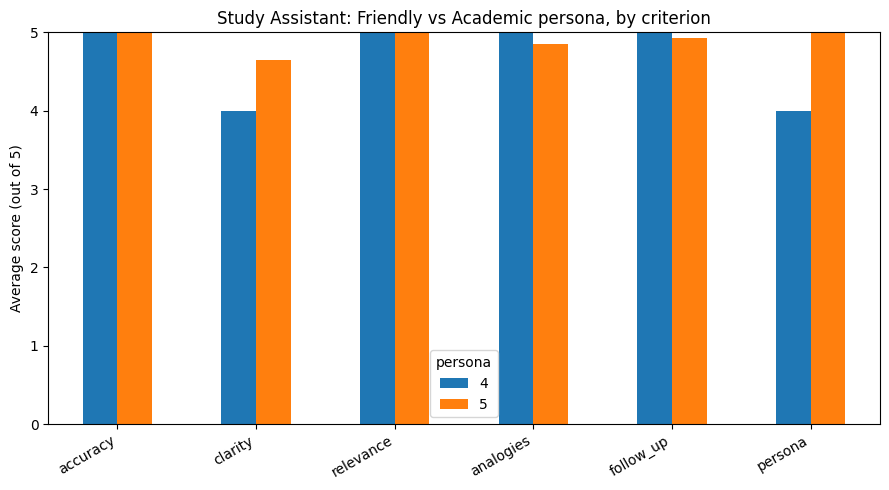


Saved raw results to eval_results.csv
Saved chart to persona_comparison.png


In [11]:
# ============================================================
# LLM Evaluation Framework — Study Assistant
# Extends the original single-example notebook into a real
# evaluation pipeline: a test dataset, three scoring methods,
# aggregation, and cross-method agreement analysis.
# ============================================================

# ---- 1. Setup ------------------------------------------------
# !pip install -U -q groq google-genai deepeval pandas matplotlib

from google.colab import userdata
from groq import Groq
from groq import RateLimitError as GroqRateLimitError, APIStatusError as GroqAPIStatusError
from google import genai
from google.genai.errors import ClientError, ServerError
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
import time

groq_client = Groq(api_key=userdata.get("GROQ_API_KEY"))
gemini_client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

# The judge model runs on Groq (generous free tier), while the Study
# Assistant itself also runs on Groq. This wrapper retries on rate
# limits (429) and temporary server overload (503) from either
# provider instead of crashing the whole run.

def call_with_retry(fn, *args, max_retries=5, **kwargs):
    for attempt in range(max_retries):
        try:
            return fn(*args, **kwargs)
        except ClientError as e:
            if e.code == 429:
                wait_s = 60
                try:
                    for detail in e.details.get("error", {}).get("details", []):
                        if "retryDelay" in detail:
                            wait_s = int(float(detail["retryDelay"].rstrip("s"))) + 2
                except Exception:
                    pass
                print(f"  Rate limited (429, Gemini). Waiting {wait_s}s before retry ({attempt+1}/{max_retries})...")
                time.sleep(wait_s)
            else:
                raise
        except ServerError as e:
            if e.code == 503:
                wait_s = 15 * (attempt + 1)
                print(f"  Model overloaded (503, Gemini). Waiting {wait_s}s before retry ({attempt+1}/{max_retries})...")
                time.sleep(wait_s)
            else:
                raise
        except GroqRateLimitError as e:
            wait_s = 20 * (attempt + 1)  # Groq doesn't always give a retry-after, so use gentle backoff
            print(f"  Rate limited (429, Groq). Waiting {wait_s}s before retry ({attempt+1}/{max_retries})...")
            time.sleep(wait_s)
        except GroqAPIStatusError as e:
            if e.status_code in (500, 502, 503, 504):
                wait_s = 15 * (attempt + 1)
                print(f"  Groq server error ({e.status_code}). Waiting {wait_s}s before retry ({attempt+1}/{max_retries})...")
                time.sleep(wait_s)
            else:
                raise
    raise RuntimeError("Max retries exceeded on API errors (429/503).")

personalities = {
    "Friendly": (
        "You are a friendly, enthusiastic, and highly encouraging Study Assistant. "
        "Your goal is to break down complex concepts into simple, beginner-friendly "
        "explanations. Use analogies and real-world examples that beginners can relate "
        "to. Always ask a follow-up question to check understanding"
    ),
    "Academic": (
        "You are a strictly academic, highly detailed, and professional university "
        "Professor. Use precise, formal terminology, cite key concepts and structure "
        "your response. Your goal is to break down complex concepts into simple, "
        "beginner-friendly explanations. Use analogies and real-world examples that "
        "beginners can relate to. Always ask a follow-up question to check understanding"
    ),
}


def study_assistant(question: str, persona: str) -> str:
    system_prompt = personalities[persona]
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": question},
        ],
    )
    return response.choices[0].message.content


# ---- 2. Test dataset ------------------------------------------
# 10 questions x 2 personas = 20 test cases. Spans easy/medium/hard
# so the eval isn't just testing one difficulty level.

TEST_QUESTIONS = [
    {"question": "What are LLMs?", "difficulty": "easy"},
    {"question": "What is the difference between supervised and unsupervised learning?", "difficulty": "easy"},
    {"question": "How does gradient descent work?", "difficulty": "medium"},
    {"question": "What is overfitting and how do you prevent it?", "difficulty": "medium"},
    {"question": "Explain the attention mechanism in transformers.", "difficulty": "hard"},
    {"question": "What is backpropagation?", "difficulty": "medium"},
    {"question": "Why do neural networks need activation functions?", "difficulty": "medium"},
    {"question": "What is the difference between precision and recall?", "difficulty": "easy"},
    {"question": "How does reinforcement learning from human feedback (RLHF) work?", "difficulty": "hard"},
    {"question": "What is the vanishing gradient problem?", "difficulty": "hard"},
]

TEST_CASES = [
    {"question": q["question"], "difficulty": q["difficulty"], "persona": persona}
    for q in TEST_QUESTIONS
    for persona in personalities.keys()
]  # -> 20 test cases. Judge is now Groq (llama-3.3-70b-versatile), which has a
   # much more generous free tier than Gemini did, so running all 20 in one
   # go should work. If you still hit a Groq rate limit, uncomment below.

# TEST_CASES = TEST_CASES[:10]  # uncomment to run a smaller batch first


# ---- 3. Manual LLM-as-judge -----------------------------------

EVAL_PROMPT = """You are an expert evaluator for AI assistants.

Evaluate the Study Assistant's response based on these 6 criteria.
Score each from 1-5 (5 = excellent, 3 = acceptable, 1 = poor).

## Evaluation Criteria:

1. **Accuracy** (1-5): Is the information factually correct?
2. **Clarity** (1-5): Is it easy for a beginner (12th class student) to understand?
3. **Relevance** (1-5): Does it directly answer the question asked?
4. **Use of Analogies** (1-5): Does it use real-world examples or analogies?
5. **Follow-up Question** (1-5): Does it include a question to check understanding?
6. **Persona Consistency** (1-5): Does the tone match the expected persona?
   - "Friendly": enthusiastic, encouraging, warm
   - "Academic": formal, precise, professional

## Input Details:

**Student Question:** {question}
**Expected Persona:** {persona}
**Assistant Response:** {response}

## Your Evaluation:

Respond in EXACTLY this format (numbers only, no extra text):

ACCURACY: [score]
CLARITY: [score]
RELEVANCE: [score]
ANALOGIES: [score]
FOLLOW_UP: [score]
PERSONA: [score]
"""


def evaluate_response(question: str, persona: str, response: str) -> dict:
    prompt = EVAL_PROMPT.format(question=question, persona=persona, response=response)
    result = call_with_retry(
        groq_client.chat.completions.create,
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
    )
    text = result.choices[0].message.content

    scores = {}
    for criterion in ["ACCURACY", "CLARITY", "RELEVANCE", "ANALOGIES", "FOLLOW_UP", "PERSONA"]:
        match = re.search(rf"{criterion}:\s*(\d)", text)
        scores[criterion.lower()] = int(match.group(1)) if match else None
    return scores


# ---- 4. DeepEval metrics ---------------------------------------
# !pip install -q deepeval

from deepeval.models import DeepEvalBaseLLM
from deepeval.metrics import AnswerRelevancyMetric, GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams


class GroqDeepEvalModel(DeepEvalBaseLLM):
    """Wraps our Groq client so DeepEval's metrics use Groq as the judge
    instead of Gemini — avoids the Gemini free-tier daily quota entirely."""

    def __init__(self, model_name="llama-3.3-70b-versatile"):
        self.model_name = model_name

    def load_model(self):
        return groq_client

    def generate(self, prompt: str) -> str:
        response = call_with_retry(
            groq_client.chat.completions.create,
            model=self.model_name,
            messages=[{"role": "user", "content": prompt}],
        )
        return response.choices[0].message.content

    async def a_generate(self, prompt: str) -> str:
        return self.generate(prompt)

    def get_model_name(self):
        return self.model_name


groq_judge = GroqDeepEvalModel()

relevance_metric = AnswerRelevancyMetric(threshold=0.7, model=groq_judge, include_reason=True)

accuracy_metric = GEval(
    name="Accuracy",
    criteria=(
        "Determine if the response contains factually correct information about the "
        "topic. The explanation should be accurate and free from errors. Students "
        "should not learn incorrect concepts."
    ),
    evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
    model=groq_judge,
    threshold=0.7,
)


def run_deepeval(question: str, response: str, max_retries: int = 3) -> dict:
    test_case = LLMTestCase(input=question, actual_output=response)

    # DeepEval's metrics expect the judge model to return clean JSON internally.
    # Groq models occasionally return malformed JSON (unlike Gemini's structured
    # output mode), so retry a few times — regenerating usually fixes it.
    for attempt in range(max_retries):
        try:
            call_with_retry(relevance_metric.measure, test_case)
            call_with_retry(accuracy_metric.measure, test_case)
            break
        except Exception as e:
            if "invalid JSON" in str(e) and attempt < max_retries - 1:
                print(f"  Judge returned malformed JSON, retrying ({attempt+1}/{max_retries})...")
                time.sleep(3)
            else:
                raise

    return {
        "deepeval_relevancy_score": relevance_metric.score,
        "deepeval_relevancy_pass": relevance_metric.is_successful(),
        "deepeval_accuracy_score": accuracy_metric.score,
        "deepeval_accuracy_pass": accuracy_metric.is_successful(),
    }


# ---- 5. Run the full pipeline across the test set ---------------

def run_evaluation_suite(test_cases: list, save_path: str = "eval_results_partial.csv") -> pd.DataFrame:
    rows = []
    for i, case in enumerate(test_cases):
        question = case["question"]
        persona = case["persona"]
        difficulty = case["difficulty"]

        print(f"[{i+1}/{len(test_cases)}] {persona} — {question[:50]}...")

        try:
            response = study_assistant(question, persona)
            manual_scores = evaluate_response(question, persona, response)
            deepeval_scores = run_deepeval(question, response)
        except Exception as e:
            print(f"  Failed on this case ({e}). Saving progress so far and stopping.")
            break
        time.sleep(2)  # small pacing gap between test cases

        row = {
            "question": question,
            "persona": persona,
            "difficulty": difficulty,
            "response": response,
            **manual_scores,
            **deepeval_scores,
        }
        rows.append(row)

        # Save after every single test case — never lose completed work to a crash again
        pd.DataFrame(rows).to_csv(save_path, index=False)

    return pd.DataFrame(rows)


# ---- 6. Aggregation + reporting ----------------------------------

def summarize(df: pd.DataFrame):
    if df.empty:
        print("\nNo completed test cases yet — nothing to summarize.")
        print("This usually means the run hit a rate limit before finishing even one case.")
        return None

    manual_cols = ["accuracy", "clarity", "relevance", "analogies", "follow_up", "persona"]

    print("\n=== Average manual-judge scores (out of 5) ===")
    print(df[manual_cols].mean().round(2))

    print("\n=== Average manual-judge scores by persona ===")
    print(df.groupby("persona")[manual_cols].mean().round(2))

    print("\n=== Average manual-judge scores by difficulty ===")
    print(df.groupby("difficulty")[manual_cols].mean().round(2))

    print("\n=== DeepEval pass rates ===")
    print("Relevancy pass rate:", df["deepeval_relevancy_pass"].mean())
    print("Accuracy pass rate:", df["deepeval_accuracy_pass"].mean())

    # Cross-method agreement: does the manual judge's accuracy score (>=4 = "pass")
    # agree with DeepEval's GEval accuracy pass/fail?
    df["manual_accuracy_pass"] = df["accuracy"] >= 4
    agreement = (df["manual_accuracy_pass"] == df["deepeval_accuracy_pass"]).mean()
    print(f"\n=== Manual judge vs GEval accuracy agreement: {agreement:.0%} ===")

    return agreement


def plot_persona_comparison(df: pd.DataFrame, out_path="persona_comparison.png"):
    if df.empty:
        print("No completed test cases yet — skipping chart.")
        return

    manual_cols = ["accuracy", "clarity", "relevance", "analogies", "follow_up", "persona"]
    grouped = df.groupby("persona")[manual_cols].mean()

    ax = grouped.T.plot(kind="bar", figsize=(9, 5))
    ax.set_ylabel("Average score (out of 5)")
    ax.set_title("Study Assistant: Friendly vs Academic persona, by criterion")
    ax.set_ylim(0, 5)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()


# ---- 7. Main --------------------------------------------------

if __name__ == "__main__":
    results_df = run_evaluation_suite(TEST_CASES)  # also saves progress live to eval_results_partial.csv

    # Merge with a previous session's results if you uploaded eval_results.csv
    # back into Colab before running this batch.
    import os
    if os.path.exists("eval_results.csv") and os.path.getsize("eval_results.csv") > 0:
        try:
            existing_df = pd.read_csv("eval_results.csv")
            results_df = pd.concat([existing_df, results_df], ignore_index=True)
            results_df = results_df.drop_duplicates(subset=["question", "persona"], keep="last")
            print(f"Merged with previous session — now {len(results_df)} total rows.")
        except pd.errors.EmptyDataError:
            print("eval_results.csv exists but is empty/corrupt — skipping merge, using this run's results only.")

    results_df.to_csv("eval_results.csv", index=False)

    agreement_rate = summarize(results_df)
    plot_persona_comparison(results_df)

    print("\nSaved raw results to eval_results.csv")
    if agreement_rate is not None:
        print("Saved chart to persona_comparison.png")
    else:
        print("(No chart generated — no completed test cases in this run.)")
